# Test setup at Heligoland
This notebook documents the general test setup, locations and more information for the validation measurements at Heligoland. 


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lidalign.utils import load_template, publication_figure

import plotly.graph_objects as go
from PIL import Image
import skimage.io as sio

load_template()
import pathlib 
savepath = pathlib.Path.home()  /'Figures'
savepath.mkdir(exist_ok=True)

Using lidar_monitoring.mplstyle as matplotlib style template


## Visualization of the site

In [14]:
positions = pd.read_csv('data/HELGOHARB 20250503.csv', header = None, names = ['Position','X','Y','Z','Type'], index_col= 'Position')
pos_rel = positions.copy()
pos_rel[['X','Y','Z']] -= positions.loc['LIDARHEAD',['X','Y','Z']].astype(float)
pos_rel.loc['Watercorner'] = pos_rel.loc['CORNER 2'].copy()
pos_rel = pos_rel.dropna(axis = 0, how = 'any')



pos_rel['azimuth'] = np.rad2deg(np.arctan2(pos_rel['X'], pos_rel['Y'])) #np.rad2deg(np.arctan2(pos_rel['X'], pos_rel['Y']))
pos_rel['elevation'] =  np.rad2deg(np.arctan(pos_rel['Z'] / (pos_rel['X']**2 + pos_rel['Y']**2)**0.5))

pos_rel['Distance'] = np.sum(pos_rel[['X','Y','Z']]**2, axis = 1)**0.5
print(pos_rel['Distance']) ## reference is corner2!
aim = pos_rel.loc['Watercorner']
print()
print(aim)



Position
STATION A       20.579809
CORNER 1       171.538760
CORNER 2       171.583166
CORNER 3       157.601132
CORNER 4       143.303444
LIDARLEG1        1.334438
LIDARLEG2        1.294822
LIDARLEG3        1.313251
LIDARHEAD        0.000000
C6             171.523649
C7             171.565801
STATION B        3.764995
Watercorner    171.583166
Name: Distance, dtype: float64

X               168.525
Y               -31.603
Z                -6.431
Type                  P
azimuth      100.621154
elevation      -2.14797
Distance     171.583166
Name: Watercorner, dtype: object


In [15]:
pos_rel

,X,Y,Z,Type,azimuth,elevation,Distance
Position,,,,,,,
STATION A,20.365,2.964,-0.100,ST,81.719098,-0.278409,20.579809
CORNER 1,168.569,-31.741,-1.596,P,100.663751,-0.533089,171.538760
CORNER 2,168.525,-31.603,-6.431,P,100.621154,-2.147970,171.583166
CORNER 3,156.440,-19.036,-1.508,P,96.937782,-0.548241,157.601132
CORNER 4,143.204,-5.120,-1.509,P,92.047635,-0.603342,143.303444
LIDARLEG1,-0.168,-0.580,-1.190,P,-163.846067,-63.095421,1.334438
LIDARLEG2,0.524,0.050,-1.183,P,84.549348,-66.013156,1.294822
LIDARLEG3,0.016,0.604,-1.166,P,1.517414,-62.607170,1.313251
LIDARHEAD,0.000,0.000,0.000,P,0.000000,NaN,0.000000


Background image by GDI: 
https://gdi-sh.de/gdish/DE/AufgabenZiele/DANord

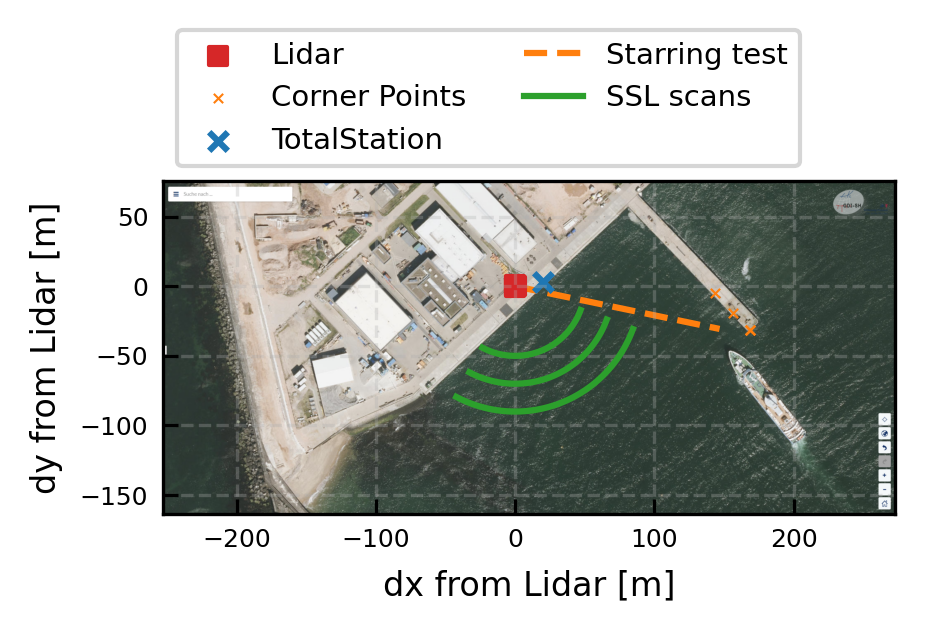

In [17]:


path = 'misc_data/pictures/TopViewHeligoland_427428_6003256_427954_6003495.png'
img = Image.open(path).convert('RGB')
img = Image.open(path).convert('RGB')
z = np.mean(np.array(img), axis=2)

left,bottom,right,top = [float(f) for f in path.replace('.png','').split('_')[-4:]]

# fig, ax = plt.subplots(1,1, figsize=(6,4), dpi = 300)
fig, ax= publication_figure(1/2)


# ax[0].text(50, 100, 'original image', fontsize=16, bbox={'facecolor': 'white', 'pad': 6})
refpos = positions.loc['LIDARHEAD',['X','Y','Z']]
l,r,b,t= left-refpos['X'], right-refpos['X'], bottom - refpos['Y'], top - refpos['Y']
ax.imshow(img, extent = (l,r,b,t))

azi_starring, range_starring = 101.8, 150
x = np.array([0,range_starring* np.sin(np.deg2rad(azi_starring))])# + refpos.loc['LIDARHEAD','X']
y = np.array([0,range_starring* np.cos(np.deg2rad(azi_starring))])# + pos_rel.loc['LIDARHEAD','Y']

pos_rel.filter(like = 'LIDAR', axis = 0).plot.scatter(x = 'X', y = 'Y', ax = ax, c= 'tab:red', label = 'Lidar', marker = 's')
pos_rel.filter(like = 'C', axis = 0).plot.scatter(x = 'X', y = 'Y', ax = ax, c= 'tab:orange', label = 'Corner Points', marker = 'x', s = 5, lw = 0.5)
pos_rel.filter(like = 'STATION A', axis = 0).plot.scatter(x = 'X', y = 'Y', ax = ax, c= 'tab:blue', label = 'TotalStation', marker = 'x')

ax.plot(x,y, c = 'tab:orange', ls = '--', zorder = 0, label = 'Starring test')

azi = np.arange(110,210,2)
ranges = np.array([50,70,90])
xpo, ypo = np.sin(np.deg2rad(azi))[:,np.newaxis]*ranges[np.newaxis,:], np.cos(np.deg2rad(azi))[:,np.newaxis]*ranges[np.newaxis,:]
ax.plot(xpo, ypo, c = 'tab:green')
ax.plot([],[],c = 'tab:green', label = 'SSL scans')
ax.set(xlabel = 'dx from Lidar [m]', ylabel = 'dy from Lidar [m]')
ax.legend(loc = 'lower left', bbox_to_anchor = (-0,1), ncols = 2)
ax.set_aspect('equal')
plt.savefig(savepath / 'TopView.pdf', bbox_inches = 'tight')


## Lidar time correction:

Unfortunately, the time was not correctly set by the lidar. The measurements were performed `2025-05-03` while the lidar gives dates of `2010-01-02`. We correct the time for an offset determined from pictures and actual lidar observations. We estimate the uncertainty to be ~1min.
Therefore, we must correct the times in the lidar:

In [5]:
import pandas as pd
time_difference_lidar_actual = pd.to_datetime('2025-05-03 10:37') - pd.to_timedelta('2h') - pd.to_datetime('2010-01-02 15:51:32') ## PC time - Lidar time - correction for UTC
time_difference_lidar_actual

Timedelta('5599 days 16:45:28')

## Hard target mapping 

We will here use the correct (theodilite) azimuth values to correct our lidar elevation. First, we correct the lidar azimuth, then we use the corrected lidar azimuth to correct the lidar elevation. 

In [15]:
%matplotlib inline
from lidalign.hard_target_elevation_mapping import HardTargetMappingElevation
fitti = pd.read_excel(r'data/Hard_target_mapping_with_fitting.xlsm', sheet_name='HTM')

fitti = fitti.dropna(subset ='Delta Ele')
# print(fitti)
HTM = HardTargetMappingElevation(fitti['Theo_Azimuth'].values, 
                           fitti['Delta Ele'].values, 
                           fitti['Unc_azi'].values, fitti['Unc_ele'].values
                           )

#%%

# HTM.fit(typ = 'cosine')
# print(HTM.params)
# fig, ax = publication_figure(1, height = 3)
# ax = HTM.plot(ax = ax)

HTM.fit(typ = 'Other')
print(HTM.params)


C:\Users\Paul\Code\packages\own\lidalign\lidalign\hard_target_elevation_mapping.py:86: OptimizeWarning:

Covariance of the parameters could not be estimated



        mean   std    form
0  322.91118  0.02  normal
1  127.97466  0.02  normal
2   64.84780  0.02  normal
      mean   std    form
0  0.35087  0.02  normal
1  0.22672  0.02  normal
2  0.23092  0.02  normal
Other


Performing Monte Carlo Iterations: 100%|██████████| 1000/1000 [00:02<00:00, 496.44it/s]

[-0.01262319 -0.07641097  0.29472066]


(1000, 360)


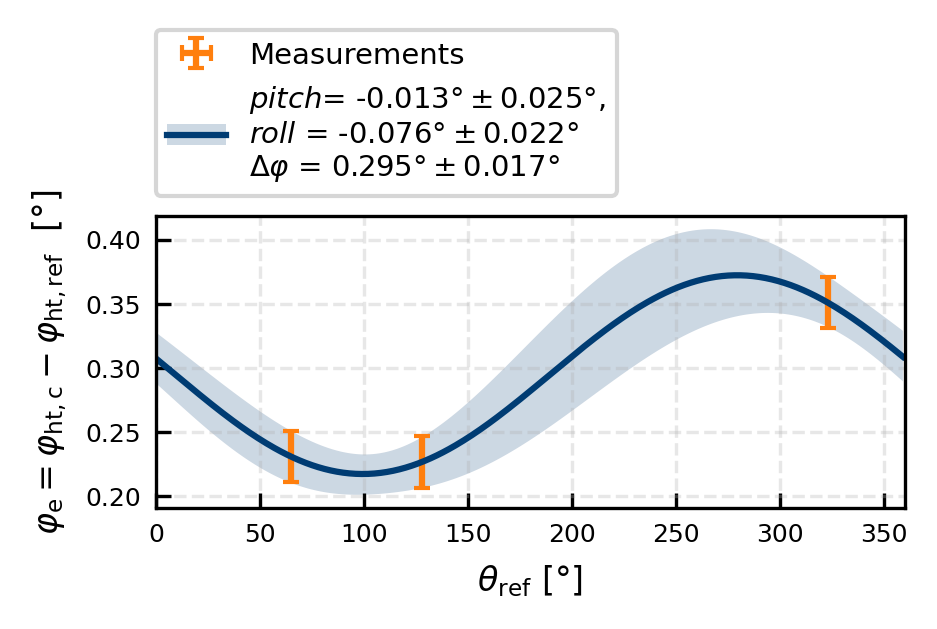

In [31]:
fig, ax = publication_figure(1/2, height = 2.3)
ax = HTM.plot(ax= ax)
leg = ax.get_legend()
ax.set(ylabel = r'$\varphi_{\rm e}= \varphi_{\rm ht,c} - \varphi_{\rm ht,ref}$  [°]', xlabel = r'$\theta_{\rm ref}$ [°]', xlim = (0,360))

ax.set(title = None)
leg.set_bbox_to_anchor((-0.02, 1.02))  # outside right of axes
leg.set_loc("lower left")

plt.savefig(savepath + 'HardTargetMapping_Elevation.pdf', bbox_inches = 'tight', pad_inches = 0.00001)

# # -------------------------- with lidar azimuth as x ------------------------- #

# HTM = HardTargetMappingElevation(fitti['Azimuth'].values, 
#                            fitti['Delta Ele'].values, 
#                            fitti['Unc_azi'].values, fitti['Unc_ele'].values
#                            )

# #%%
# HTM.fit()
# params = HTM.params
# print(params)
# #%%
# ax = HTM.plot()

### Derived scanner offset correction

[ 3.92955323  0.04550043 41.85572916]
[3.22039521e+02 4.55247703e-02 4.18557071e+01]


C:\Users\Paul\Code\packages\own\lidalign\lidalign\hard_target_elevation_mapping.py:99: OptimizeWarning:

Covariance of the parameters could not be estimated



[Text(65.70833333333333, 0.5, '$\\Delta \\Theta$ (lidar-reference) [deg]'),
 Text(0.5, 35.58333333333332, '$\\Theta$ (lidar) [deg]')]

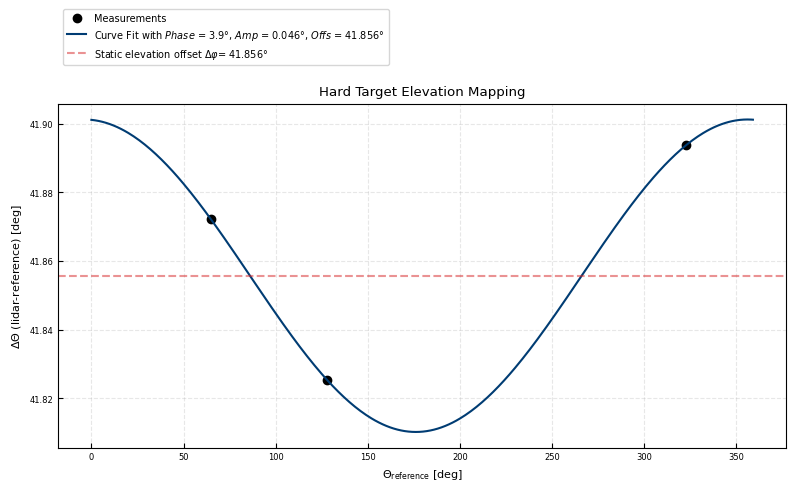

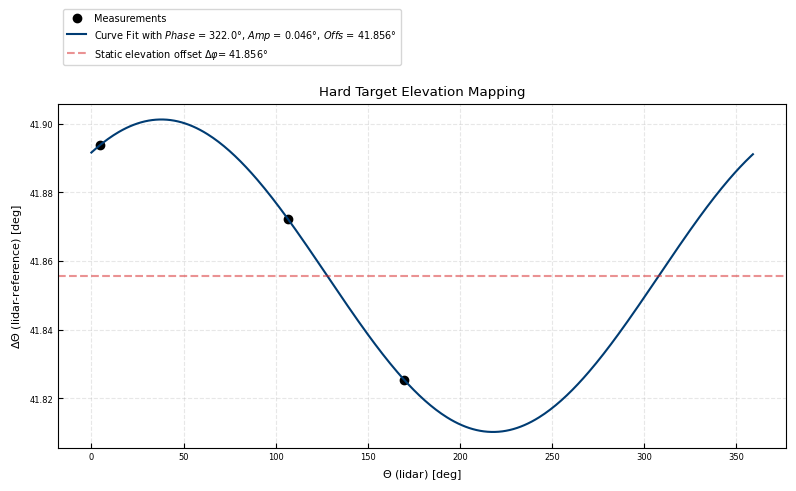

In [ ]:
HTM = HardTargetMappingElevation(fitti['Theo_Azimuth'].values, 
                           ((fitti['Delta Azi'].values)+180 ) %360 -180,  
                                                   #    fitti['Unc_azi'].values, fitti['Unc_ele'].values
                                                                              )
                                                                              # params = HardTargetMappingElevation.fit_TaitBryanAngles(fitti['Theo_Azimuth'].values, 
                                                                              #                         fitti['Theo_Elevation'].values, 
                                                                              #                         (fitti['Azimuth'].values-41.87)%360, fitti['Elevation'].values)
                                                                              # print(params)

                                                                              #%%
                                                                              HTM.fit()
                                                                              params = HTM.params
                                                                              print(params)
                                                                              #%%
                                                                              ax = HTM.plot()
                                                                              ax.set(ylabel = r'$\Delta \Theta$ (lidar-reference) [deg]')


                                                                              # ----------------------- as function of lidar azimuth ----------------------- #
                                                                              HTM = HardTargetMappingElevation(fitti['Azimuth'].values, 
                                                                                                         ((fitti['Delta Azi'].values)+180 ) %360 -180,  
                                                                                                                                 #    fitti['Unc_azi'].values, fitti['Unc_ele'].values
                                                                                                                                                            )
                                                                                                                                                            # params = HardTargetMappingElevation.fit_TaitBryanAngles(fitti['Theo_Azimuth'].values, 
                                                                                                                                                            #                         fitti['Theo_Elevation'].values, 
                                                                                                                                                            #                         (fitti['Azimuth'].values-41.87)%360, fitti['Elevation'].values)
                                                                                                                                                            # print(params)

                                                                                                                                                            #%%
                                                                                                                                                            HTM.fit()
                                                                                                                                                            params = HTM.params
                                                                                                                                                            print(params)
                                                                                                                                                            #%%
                                                                                                                                                            ax = HTM.plot()
                                                                                                                                                            ax.set(ylabel = r'$\Delta \Theta$ (lidar-reference) [deg]', xlabel = r'$\Theta$ (lidar) [deg]')

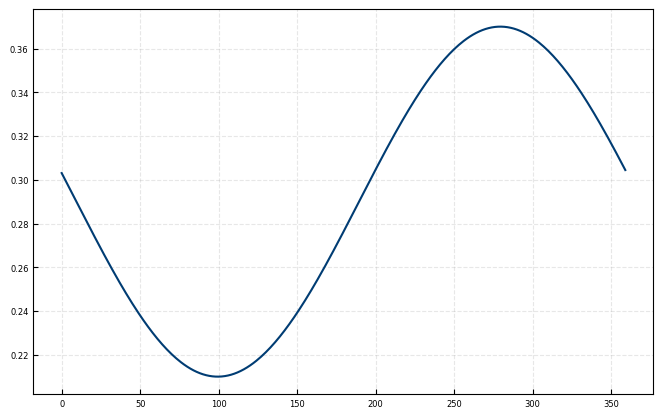

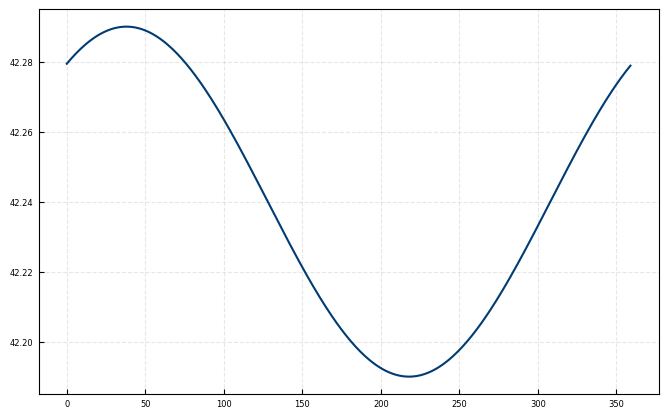

In [9]:
def angle_offset_function(azimuth, phase, amplitude, offset):
    return np.cos(np.deg2rad(phase + azimuth))* amplitude + offset

azimuth_phase = 322
azimuth_ampl = 0.05
azimuth_offset = 41.86 + 0.38 # 0.38° repositioning offset, theodilite has been moved and not perfectly aligned with first positions

# elevation_offset = 0.217 # approximately for azi =100° from HTM

elevation_phase = 80.6
elevation_ampl = 0.08
elevation_offset = 0.29

azis = np.arange(0,360)
fig,ax = plt.subplots()
ax.plot(azis, angle_offset_function(azis, 80.6, 0.08, 0.29))



fig,ax = plt.subplots()
ax.plot(azis, angle_offset_function(azis, azimuth_phase, azimuth_ampl, azimuth_offset))

## Water level impact
During the measurements, we observed a variation of the water level with time, caused by tidal variations of the water level within the harbour. We found a reference water level measurement in the harbour from [this database](https://www.pegelonline.wsv.de/gast/stammdaten?pegelnr=9510070), provided by the Wasserstraßen und Schiffahrtsverwaltung des Bundes.

We estimate the uncertainty to be ~0.1m. 

In the following, the water level variations during the different scans are shown. 

Height difference during measurement period Starring: 0.070 m


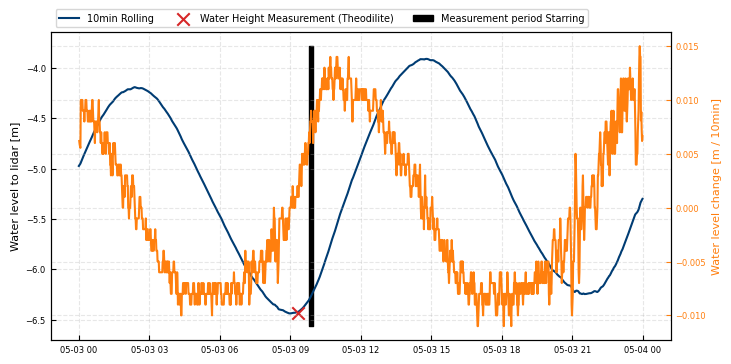

In [10]:
t_waterheight_measurement, water_height_measurement = pd.to_datetime('2025-05-03 09:19:11'), -6.431 ## from screenshot and theodilite
import matplotlib.dates as mdates

t0 = pd.to_datetime('2025-05-03T09:47:50.223')
t1 = pd.to_datetime('2025-05-03T09:56:59.553')

import pandas as pd
water_level_df = pd.read_csv(r'data/water_level/pegelonline-helgolandbinnenhafen-W-20250101-20250820.csv', sep = ';', parse_dates = True, index_col = 0)
water_level_df.index = water_level_df.index - pd.Timedelta(hours = 2)  # adjust for UTC
water_level_df = water_level_df.loc['2025-05-03']
water_level_df = water_level_df / 100 # in meters

# -------------- correct for actual height of lidar above water -------------- #

ref_height = water_level_df.loc[t_waterheight_measurement:].values[0]
water_level_lidar = water_level_df - ref_height + water_height_measurement


fig, ax = plt.subplots(figsize=(8, 4))
roll = water_level_lidar.rolling('10min', center = True).mean()
ax.plot(roll, label = '10min Rolling')

ax.scatter(t_waterheight_measurement, water_height_measurement, color='tab:red', marker = 'x', label='Water Height Measurement (Theodilite)', zorder = 100, s = 80)

ax.fill_betweenx(ax.get_ylim(), t0, t1, color='k', alpha=1, label = 'Measurement period Starring')
print(f"Height difference during measurement period Starring: {np.diff(water_level_lidar.loc[t0:t1].values[[0,-1]].T[0])[0]:.3f} m")
# ax.axvline(t0)
# ax.axvline(t1)
# ax.fill_between([t0, t1], [400,600])
axd = ax.twinx()
axd.plot(roll.index, roll.diff(), c = 'tab:orange')
axd.set(ylabel = 'Water level change [m / 10min]')
axd.yaxis.label.set_color('tab:orange')
axd.tick_params(axis='y', colors='tab:orange')

ax.set(ylabel = 'Water level to lidar [m]')


# ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend(loc = 'lower left', bbox_to_anchor=(0, 1), ncols = 3)

### During Starring Test:

[0.07] value   -4.407553
dtype: float64 value    0.02
Name: 2025-05-03 09:49:00, dtype: float64
10cm water level difference can lead to 6.30m Range difference


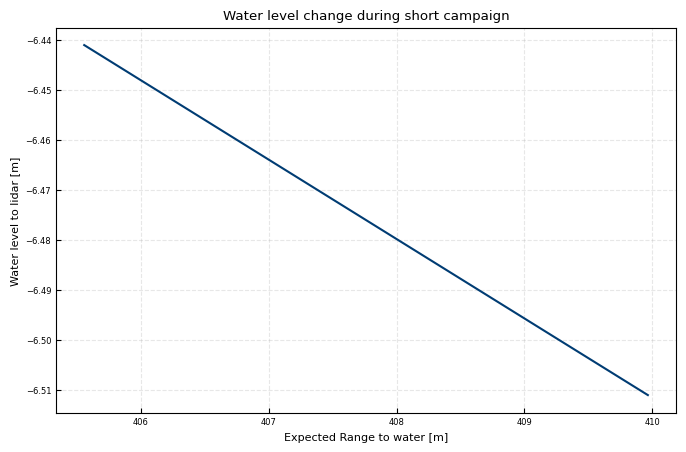

In [11]:
elevation = -0.910

delta_height = 0.2
fig, ax =plt.subplots()
R = (water_level_lidar.loc[t0:t1]-delta_height)/ np.sin(np.deg2rad(elevation))
ax.plot(R, water_level_lidar.loc[t0:t1]-delta_height)

print(np.diff(water_level_lidar.loc[t0:t1].values[[0,-1]].T[0]), R.iloc[-1]-R.iloc[0], water_level_lidar.loc[t0:t1].diff().iloc[1])
ax.set(xlabel = 'Expected Range to water [m]', ylabel = 'Water level to lidar [m]', title= 'Water level change during short campaign')

print(f'10cm water level difference can lead to {-0.1 /np.sin(np.deg2rad(elevation)):.2f}m Range difference')

### During the SSC test:

Mean water level during SCC: -6.18 m
std water level during SCC: 0.02 m


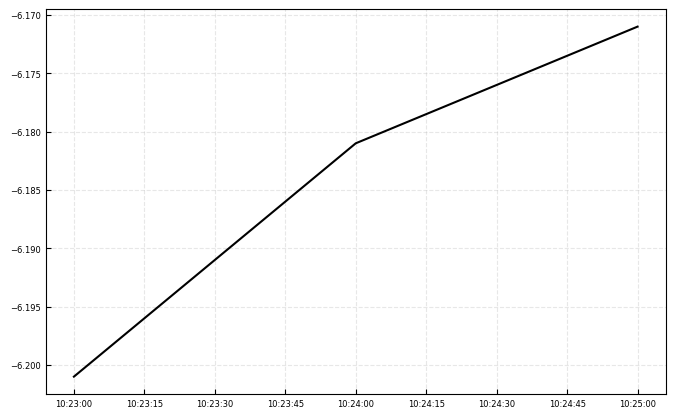

In [12]:
elevation = -0.910

delta_height = 0.20
fig, ax =plt.subplots()

waterlevel_scc = (water_level_lidar.loc['2025-05-03T10:22:07.934000000':'2025-05-03T10:25:35.606000000']-delta_height)
ax.plot(waterlevel_scc.index, waterlevel_scc, label = 'Expected Range to water', c = 'k')

print(f'Mean water level during SCC: {waterlevel_scc.mean().values[0]:.2f} m')
print(f'std water level during SCC: {waterlevel_scc.std().values[0]:.2f} m')


## Hard target results (not evaluated here)

In [13]:
from lidalign.io import WindCubeScanDB
DBS = WindCubeScanDB(r'C:\Users\Paul\Nextcloud\Harbour Test\Harbour Test\\', datatype = 'scans', file_structure='flat')
metadata = DBS.get_data()
metadata.to_excel(savepath + 'ScansOverview.xlsx')

Finding all files for scans
	 --> 328 files found
	 Filtering for 2025-01-01 00:00:00+00:00 to 2026-01-12 15:39:04.896081, None 
	 --> 328 files found for given regex and time range


UnboundLocalError: cannot access local variable 'ds' where it is not associated with a value

In [ ]:
# group = ['HardTarget_HTM TOwer3_ppi','HardTarget_Safety2_ppi','HardTarget_safety6_ppi','HelgoHarbour_ppi1',
#          'HardTarget_Corner25m_ppi','HardTarget_Corner25_ppi','HardTarget_c25_ppi','HardTarget_c50_ppi', 
#          'HardTarget_HTM TOwer2_ppi']
if False:
    DBS = WindCubeScanDB(r'C:\Users\Paul\Nextcloud\Harbour Test\Harbour Test\\', datatype = 'scans', file_structure='flat')
    metadata = DBS.get_data()
    metadata.to_excel(savepath + 'ScansOverview.xlsx')

    groups = [g for g in metadata['group_names'].unique() if 'ppi' in g and 'HardTarget' in g] 

    # groups = ['HardTarget_safety6_ppi']

    for group in groups:
        fileids = sorted(metadata.loc[metadata['group_names']==group,'identifier'])

        htmdata = DB.get_data(filename_regex='|'.join([str(id) for id in fileids]))
        # if len(htmdata)>len(fileids):
            


        import pandas as pd 

        fig, ax = plt.subplots(figsize = (12,8))
        for htmd in htmdata:
            # ax.scatter(htmd['azimuth'], htmd['elevation'], c= htmd['cnr'].max(dim = 'range'), vmin = -5, vmax = 5)
            cb = ax.scatter(htmd['azimuth'], htmd['elevation'], c= htmd['cnr'].idxmax(dim = 'range'))
        plt.colorbar(cb, ax = ax)

        ax.set_aspect('equal')
        ax.set(xlabel = 'Azimuth [deg]', ylabel = 'Elevation [deg]', title = group)
        plt.savefig(r'C:\Users\Paul\Nextcloud\Harbour Test\CNRmaps\\' + f"{group}_{pd.to_datetime(htmdata[0].time.values[0]).strftime('%Y%m%d-%H%M')}.jpg")
        plt.close(fig)
